# Finetune and test EQtransformer, EQCCT and Phasenet from Seisbench 

!pip install seisbench
!unzip waveforms.zip

In [1]:
import seisbench.data as sbd
import seisbench.util as sbu
import seisbench.generate as sbg
import seisbench.models as sbm
from seisbench.util import worker_seeding

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import os, obspy, json, datetime
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import train_utils as tutils
import model_utils as mutils

# ----------- eqdet directories ----------- 
EQDET_DIR = Path("../eqdet")
EQDET_DATA_DIR = EQDET_DIR / "data"

QKML_EQ_DIR = EQDET_DATA_DIR / "qkml_earthquakes"
QKML_EX_DIR = EQDET_DATA_DIR / "qkml_explosions"

WAVEFORM_EQ_DIR = EQDET_DATA_DIR / "waveforms_earthquakes_nonoise"
WAVEFORM_EX_DIR = EQDET_DATA_DIR / "waveforms_explosions_nonoise"
WAVEFORM_NOISE_DIR = EQDET_DATA_DIR / "waveforms_noise_only"

FILENAME_WINDOWS = "windows.csv"
FILENAME_EQ_Y = "eq_labels.csv"
FILENAME_EX_Y = "ex_labels.csv"
FILENAME_NOISE_Y = "noise_labels.csv"

# ----------- eqcomp directories ----------- 
DIR_DATA = Path(os.getcwd()) / "data"
FILENAME_METADATA = "metadata.csv"
FILENAME_WAVEFORMS = "waveforms.hdf5"

FILENAME_MODEL = "model.pth"

SAMPLING_RATE = 100
TRAIN_SPLIT = 0.80
TEST_SPLIT = 0.10
WIN_LEN = 6000

## 1. Load dataset and model

In [2]:
# Load the train validation and test splits
dataset = sbd.WaveformDataset(DIR_DATA)
train_dataset, dev_dataset, test_dataset = dataset.train_dev_test()

# Load pre-trained model from seisbench Model weights are in fp32 (float)
configs = {"EQTransformer": mutils.EQTransformerConfig(),
           "EQCCTP": mutils.EQCCTConfig("P"),
           "EQCCTS": mutils.EQCCTConfig("S"),
           "PhaseNet": mutils.PhaseNetConfig()
        } # Add here

config = configs["PhaseNet"]
 
model = config.get_new_model()
model.to_preferred_device(verbose=True)

2026-08-24 16:36:25,146 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


Model device: cpu


## 2. Preprocess dataset
Complete model-specific data preprocessing and compare performance of the pretrained baselines

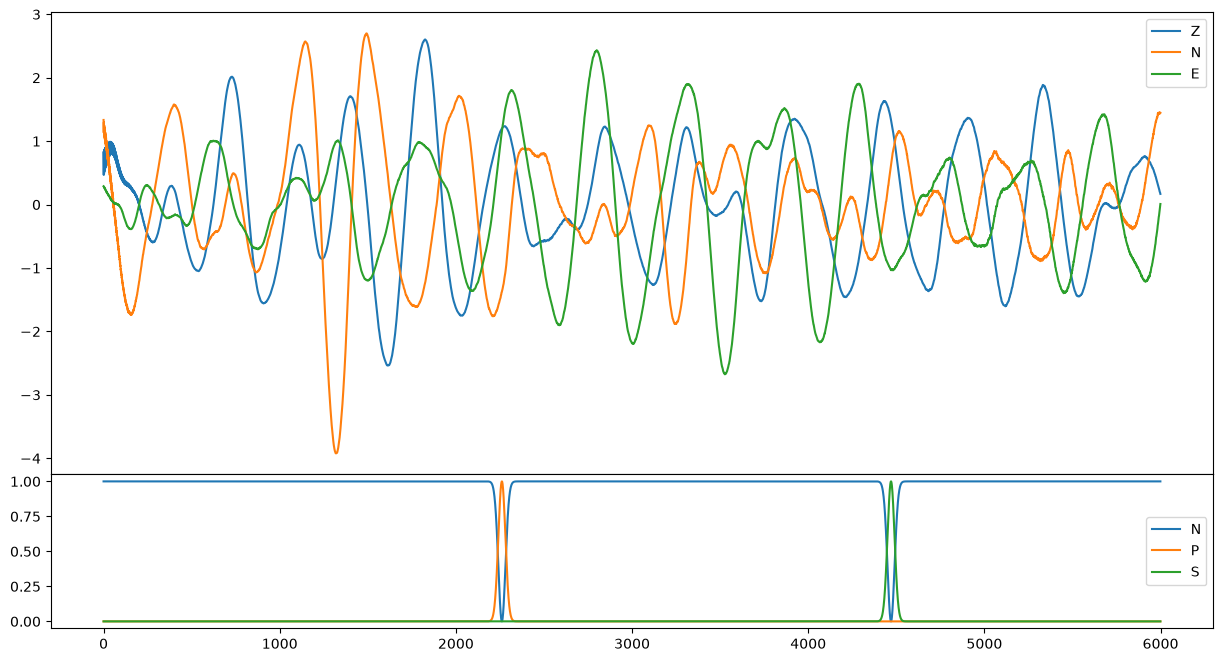

In [3]:
# Preprocess dataset
train_gen, dev_gen, test_gen = tutils.preprocess_data(config, train_dataset, dev_dataset, test_dataset)

# Plot sample for debugging
sample = train_gen[1]

fig = plt.figure(figsize=(15, 8))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0, "height_ratios": [3, 1]})

axs[0].plot(sample["X"].T, label=["Z", "N", "E"])
axs[0].legend()
axs[1].plot(sample["y"].T, label=list(model.labels))
axs[1].legend()

## 3. Finetune model

In [ ]:
batch_size = 32
num_workers = 3 # The number of threads used for loading data, 0 so that enumerate(train_loader) does not block
learning_rate = 1e-3
epochs = 1

train_loader = DataLoader(
    train_gen,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    worker_init_fn=worker_seeding,
)

dev_loader = DataLoader(
    dev_gen,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    worker_init_fn=worker_seeding,
)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Train model
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    tutils.train_loop(train_loader, config.loss_fn, model, optimizer)
    tutils.test_loop(dev_loader, config.loss_fn, model)
torch.save(model.state_dict(), FILENAME_MODEL)

Epoch 1
-------------------------------


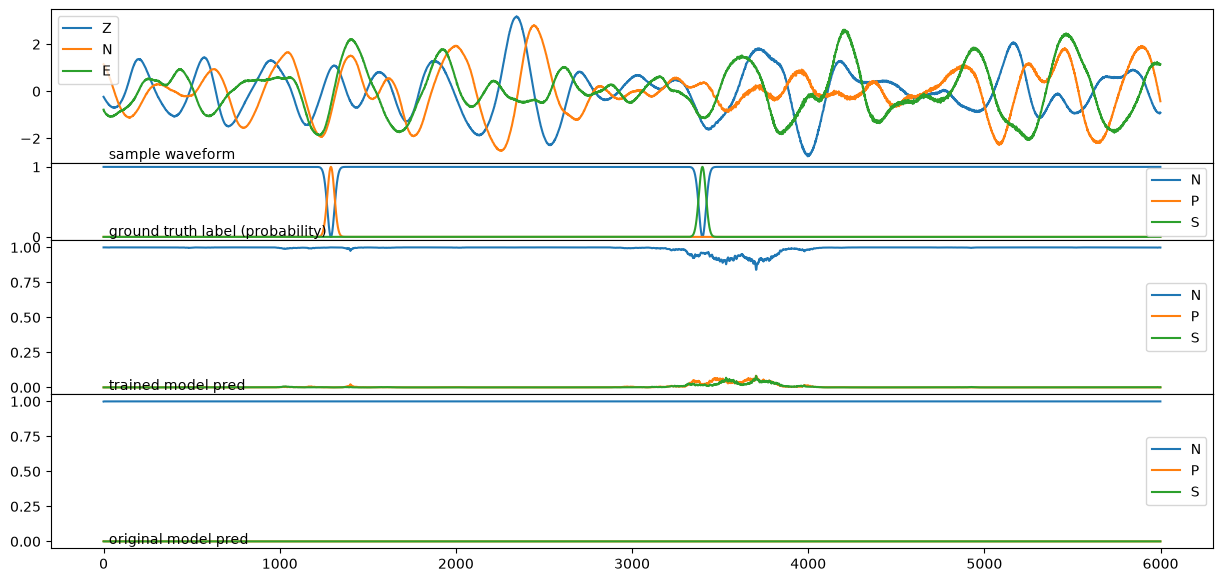

In [ ]:
# Compare predictions from finetuned and original model and plot them
sample = dev_gen[1]

trained_model = config.load_finetuned_model(FILENAME_MODEL)
org_model = config.get_new_model()

tutils.compare_preds(trained_model, org_model, sample)

## 4. Obtain metrics 
Compare finetuned and original pretrained model

In [ ]:
# --- Obtain metrics ---
results_ft = tutils.evaluate_model(trained_model, dev_gen, dev_dataset, trained_model.__class__.__name__+"-Finetuned")
results_org = tutils.evaluate_model(org_model, dev_gen, dev_dataset, org_model.__class__.__name__+"-Original")

metrics_df = tutils.aggregate_metrics(results_ft + results_org)
metrics_df

100%|██████████| 1256/1256 [00:07<00:00, 173.39it/s]


,Model,Event Type,Phase,Threshold,Count,Precision,Recall,F1,Coverage,MAE,TP,TN,FP,FN
0,PhaseNet-Finetuned,earthquakes,P,0.2,178,1.0,0.292135,0.452174,0.292135,0.081894,52,0,0,126
1,PhaseNet-Finetuned,earthquakes,P,0.5,178,1.0,0.387640,0.558704,0.387640,0.138789,69,0,0,109
2,PhaseNet-Finetuned,earthquakes,P,1.0,178,1.0,0.426966,0.598425,0.426966,0.193198,76,0,0,102
3,PhaseNet-Finetuned,earthquakes,S,0.2,178,1.0,0.185393,0.312796,0.185393,0.102541,33,0,0,145
4,PhaseNet-Finetuned,earthquakes,S,0.5,178,1.0,0.337079,0.504202,0.337079,0.212278,60,0,0,118
5,PhaseNet-Finetuned,earthquakes,S,1.0,178,1.0,0.460674,0.630769,0.460674,0.349102,82,0,0,96
6,PhaseNet-Finetuned,explosions,P,0.2,372,1.0,0.169355,0.289655,0.169355,0.076407,63,0,0,309
7,PhaseNet-Finetuned,explosions,P,0.5,372,1.0,0.295699,0.456432,0.295699,0.184810,110,0,0,262
8,PhaseNet-Finetuned,explosions,P,1.0,372,1.0,0.362903,0.532544,0.362903,0.270977,135,0,0,237
9,PhaseNet-Finetuned,explosions,S,0.2,372,1.0,0.131720,0.232779,0.131720,0.088811,49,0,0,323


# Pipelining

In [10]:
# --- Utility functions ---
def safe_serialize(value):
    """Convert non-serializable objects (like types) into strings."""
    if isinstance(value, (type, np.dtype)):
        return str(value)
    try:
        json.dumps(value)  # test if serializable
        return value
    except TypeError:
        return str
        
def serialize_augmentations(augs):
    aug_list = []
    for aug in augs:
        aug_list.append({
            "class": aug.__class__.__name__,
            "params": {k: v for k, v in aug.__dict__.items() if not k.startswith("_")}
        })
    return aug_list

def print_augmentation_summary(augs):
    print("\n--- Augmentation Pipeline ---")
    for aug in augs:
        class_name = aug.__class__.__name__
        params = {k: safe_serialize(v) for k, v in aug.__dict__.items() if not k.startswith("_")}
        print(f"{class_name}: {params}")
    print("-----------------------------\n")

In [ ]:
# --- Instantiate config ---
config = mutils.PhaseNetConfig()   # or "S", or PhaseNetConfig(), etc.

# --- Build model ---
model = config.get_new_model()
model_name = f"{model._get_name()}-Finetuned"

# --- Loss function ---
loss_fn = config.loss_fn

# --- Augmentations ---
augs = config.get_augs()
print_augmentation_summary(augs)

# --- Experiment versioning ---
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_id = f"{model_name}_{timestamp}"

experiment = {
    "id": experiment_id,
    "model_name": model_name,
    "remarks": "First try",
    "hyperparameters": {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "epochs": epochs,
        "optimizer": "Adam"
    },
    "augmentations": serialize_augmentations(augs),
    "train_loss": [],
    "val_loss": [],
    "metrics": []
}

# --- Training loop ---
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = tutils.train_loop(train_loader, loss_fn, model, optimizer)
    val_loss = tutils.test_loop(dev_loader, loss_fn, model)

    experiment["train_loss"].append(train_loss)
    experiment["val_loss"].append(val_loss)

# --- Save model weights ---
save_dir = f"experiments/{experiment_id}"
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), f"{save_dir}/{FILENAME_MODEL}")

# --- Evaluate model ---
results = tutils.evaluate_model(
    model,
    dev_gen,
    dev_dataset,
    model_name,
    mae_thresholds=[0.5]
)

metrics_df = tutils.aggregate_metrics(results)
metrics_df.to_csv(f"{save_dir}/metrics.csv", index=False)
experiment["metrics"] = metrics_df.to_dict(orient="records")

# --- Save experiment log ---
with open(f"{save_dir}/log.json", "w") as f:
    json.dump(experiment, f, indent=4)

# --- Plot losses ---
plt.figure(figsize=(8,6))
plt.plot(range(1, epochs+1), experiment["train_loss"], label="Train Loss")
plt.plot(range(1, epochs+1), experiment["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Curve - {experiment_id}")
plt.legend()
plt.savefig(f"{save_dir}/loss_curve.png")
plt.close()



--- Augmentation Pipeline ---
Normalize: {'demean_axis': -1, 'detrend_axis': None, 'amp_norm_axis': -1, 'amp_norm_type': 'std', 'eps': 1e-05, 'key': ('X', 'X')}
ProbabilisticLabeller: {'label_method': 'probabilistic', 'sigma': 20, 'shape': 'gaussian', 'labeller_type': 'probabilistic', 'polarity_column': 'trace_polarity', 'label_columns': {'trace_p_arrival_sample': 'P', 'trace_s_arrival_sample': 'S'}, 'noise_column': True, 'model_labels': ['N', 'P', 'S'], 'labels': [np.str_('P'), np.str_('S'), 'Noise'], 'label_ids': {np.str_('P'): 1, np.str_('S'): 2, 'Noise': 0}, 'label_type': 'multi_class', 'dim': 0, 'key': ('X', 'y')}
-----------------------------

Epoch 1
-------------------------------
loss: 0.036941  [    0/10042]
loss: 0.058327  [  160/10042]
loss: 0.063080  [  320/10042]
loss: 0.063618  [  480/10042]
loss: 0.062916  [  640/10042]
loss: 0.050885  [  800/10042]
loss: 0.080153  [  960/10042]
loss: 0.057525  [ 1120/10042]
loss: 0.077595  [ 1280/10042]
loss: 0.055665  [ 1440/10042]
l

100%|██████████| 1256/1256 [00:08<00:00, 152.46it/s]
